# Model Training & Evaluation — mAb Titer Prediction

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.cross_decomposition import PLSRegression
from sklearn.linear_model import ElasticNet

sns.set_theme(style="whitegrid", palette="muted")
RANDOM_STATE = 42

sys.path.insert(0, "..")
from src.features import extract_features_from_dataframe

DATA_DIR = Path("../interview_files")

# Load data and extract features
train_data = pd.read_csv(DATA_DIR / "datahow_interview_train_data.csv")
test_data = pd.read_csv(DATA_DIR / "datahow_interview_test_data.csv")
train_targets = pd.read_csv(DATA_DIR / "datahow_interview_train_targets.csv")

X_train_df = extract_features_from_dataframe(train_data)
X_test_df = extract_features_from_dataframe(test_data)
y_train = train_targets.set_index("Exp")["Y:Titer"].reindex(X_train_df.index)

duration = X_train_df["Z:ExpDuration"].astype(int)
feature_names = list(X_train_df.columns)
X_train = X_train_df.values
X_test = X_test_df.values
y = y_train.values

print(f"Train: {X_train.shape[0]} experiments, {X_train.shape[1]} features")
print(f"Test:  {X_test.shape[0]} experiments, {X_test.shape[1]} features")
print(f"Target: range [{y.min():.0f}, {y.max():.0f}], mean={y.mean():.0f}, median={np.median(y):.0f}")
print(f"\nDuration distribution:")
print(duration.value_counts().sort_index().to_string())

# Show features by group
print(f"\n=== {len(feature_names)} Features ===")
groups = {}
cw = {"VCD_at_d7", "mu_0to7", "IVCD_0to7", "fraction_ivcd_0to7", "growth_acceleration", "vcd_trajectory_shape", "days_post_temp_shift", "days_post_ph_shift"}
for f in feature_names:
    if f in cw:
        groups.setdefault("Common-window / structural", []).append(f)
    elif f.startswith("Z:"):
        groups.setdefault("Z: scalar DoE params", []).append(f)
    elif f.startswith("mu_") or f.startswith("VCD") or f == "IVCD" or f == "time_to_peak_VCD":
        groups.setdefault("VCD dynamics", []).append(f)
    else:
        groups.setdefault("Metabolite features", []).append(f)
for group, feats in groups.items():
    print(f"  {group} ({len(feats)}): {', '.join(feats)}")


Train: 100 experiments, 44 features
Test:  20 experiments, 44 features
Target: range [283, 4823], mean=1315, median=1148

Duration distribution:
Z:ExpDuration
7     30
8     20
9     20
10    20
14    10

=== 44 Features ===
  Z: scalar DoE params (13): Z:FeedStart, Z:FeedEnd, Z:FeedRateGlc, Z:FeedRateGln, Z:phStart, Z:phEnd, Z:phShift, Z:tempStart, Z:tempEnd, Z:tempShift, Z:Stir, Z:DO, Z:ExpDuration
  VCD dynamics (7): IVCD, VCD_max, VCD_end, VCD_mean, time_to_peak_VCD, mu_max, mu_early
  Metabolite features (16): Glc_end, Gln_end, Lac_end, Lac_max, Amm_end, Lysed_end, Lysed_max, int_Gln, int_Lac, int_Amm, cum_FeedGlc, cum_FeedGln, qGlc, qLac, lac_decline, gln_accumulation_ratio
  Common-window / structural (8): days_post_temp_shift, days_post_ph_shift, VCD_at_d7, IVCD_0to7, mu_0to7, fraction_ivcd_0to7, growth_acceleration, vcd_trajectory_shape


In [2]:
# Domain-driven feature pruning based on EDA findings.
# Remove features that are: pure duration proxies, exact linear combos of existing
# features, or redundant with other features in the set.

prune = [
    "int_Amm",                # partial r=-0.03 after controlling for duration — entirely a proxy
    "cum_FeedGln",            # deterministic function of Z: params (nonlinear: involves min(FeedEnd, duration))
    "days_post_temp_shift",   # = max(0, duration - tempShift), derivable from Z: params
    "days_post_ph_shift",     # = max(0, duration - phShift), same
    "Lysed_max",              # nearly identical to Lysed_end (lysis approx. monotonic, small differences in 22/100)
    "VCD_max",                # highly correlated with VCD_end (r\u22480.9); RFE can select between them
    "VCD_mean",               # approximately IVCD/duration (trapezoid vs arithmetic mean, up to ~7% difference)
    "time_to_peak_VCD",       # 76% duration confound, growth dynamics captured by mu_max/mu_early
    "gln_accumulation_ratio", # equivalent to low VCD (EDA finding), redundant with VCD features
]

keep_idx = [i for i, f in enumerate(feature_names) if f not in prune]
X_pruned = X_train[:, keep_idx]
X_test_pruned = X_test[:, keep_idx]
pruned_names = [feature_names[i] for i in keep_idx]

print(f"Pruned {len(prune)} features: {len(feature_names)} \u2192 {len(pruned_names)}")
print(f"Removed: {', '.join(prune)}")
print(f"\nRemaining {len(pruned_names)} features:")
for f in pruned_names:
    print(f"  {f}")


Pruned 9 features: 44 → 35
Removed: int_Amm, cum_FeedGln, days_post_temp_shift, days_post_ph_shift, Lysed_max, VCD_max, VCD_mean, time_to_peak_VCD, gln_accumulation_ratio

Remaining 35 features:
  Z:FeedStart
  Z:FeedEnd
  Z:FeedRateGlc
  Z:FeedRateGln
  Z:phStart
  Z:phEnd
  Z:phShift
  Z:tempStart
  Z:tempEnd
  Z:tempShift
  Z:Stir
  Z:DO
  Z:ExpDuration
  IVCD
  VCD_end
  mu_max
  mu_early
  Glc_end
  Gln_end
  Lac_end
  Lac_max
  Amm_end
  Lysed_end
  int_Gln
  int_Lac
  cum_FeedGlc
  qGlc
  qLac
  lac_decline
  VCD_at_d7
  IVCD_0to7
  mu_0to7
  fraction_ivcd_0to7
  growth_acceleration
  vcd_trajectory_shape


**Domain-driven pruning: 44 \u2192 35 features.** Removed 9 features that are redundant or confounded based on EDA findings:
- **Duration proxies** (2): int_Amm (partial r\u22480 after controlling for duration), time_to_peak_VCD (76% duration confound)
- **Deterministic from Z: params** (3): cum_FeedGln (nonlinear function of feed params and duration), days_post_temp_shift and days_post_ph_shift (= max(0, duration \u2212 shift))
- **Near-duplicates** (4): Lysed_max \u2248 Lysed_end (lysis nearly monotonic), VCD_max highly correlated with VCD_end (r\u22480.9), VCD_mean \u2248 IVCD/duration (up to ~7% difference), gln_accumulation_ratio = low VCD proxy

Note: cum_FeedGlc is kept despite similar structure because glucose feed has independent predictive value (partial r=+0.40) whereas glutamine feed is absorbed into the duration confound (partial r=+0.11).

In [3]:
# Evaluation metrics — all computed on original titer scale (not log)
def compute_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": root_mean_squared_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred),
    }

print("Metrics: MAE (primary — interpretable in titer units), RMSE, R²")

Metrics: MAE (primary — interpretable in titer units), RMSE, R²


In [4]:
# Evaluation: LOO-14d (Leave-One-Out on 14-day experiments)
# From EDA: test is 100% 14d, only 10/100 train are 14d. Standard K-Fold is biased
# under this distribution mismatch (cf. Sugiyama et al. 2007 on why standard CV
# fails under covariate shift). Our fix: LOO-14d, which directly evaluates 
# what we care about: hold out 1 of the 10 fourteen-day experiments, train on the
# remaining 99, repeat 10 times.

idx_14d = np.where(duration.values == 14)[0]
idx_short = np.where(duration.values != 14)[0]
print(f"LOO-14d: {len(idx_14d)} fourteen-day experiments, {len(idx_short)} short (always in training)")

def loo_14d(model, X, y, log_target=False):
    """Leave-one-out CV on 14-day experiments. Returns per-fold errors."""
    errors = []
    for hold_idx in idx_14d:
        train_idx = np.concatenate([idx_short, idx_14d[idx_14d != hold_idx]])
        X_tr, y_tr = X[train_idx], y[train_idx]
        
        y_fit = np.log(y_tr) if log_target else y_tr
        model.fit(X_tr, y_fit)
        pred = model.predict(X[[hold_idx]])[0]
        if log_target:
            pred = np.exp(pred)
        pred = max(pred, 0)
        errors.append(abs(y[hold_idx] - pred))
    return errors

def eval_model(model, X, y, label="", log_target=False):
    """Run LOO-14d and print results."""
    errors = loo_14d(model, X, y, log_target=log_target)
    mae = np.mean(errors)
    print(f"{label:30s}  LOO-14d MAE = {mae:.0f}  (per-fold: {', '.join(f'{e:.0f}' for e in errors)})")
    return {"label": label, "mae": mae, "errors": errors}

LOO-14d: 10 fourteen-day experiments, 90 short (always in training)


In [5]:
# Baseline: predict the training mean
class MeanPredictor:
    def fit(self, X, y): self.mean_ = y.mean(); return self
    def predict(self, X): return np.full(len(X), self.mean_)

all_results = []
all_results.append(eval_model(MeanPredictor(), X_train, y, "Baseline (predict mean)"))

Baseline (predict mean)         LOO-14d MAE = 1219  (per-fold: 712, 2665, 480, 2029, 801, 296, 417, 93, 1153, 3544)


**Baseline LOO-14d MAE = 1219.** Floor to beat. Per-fold range is huge (93 to 3544) — the 10 fourteen-day experiments have very different titers.

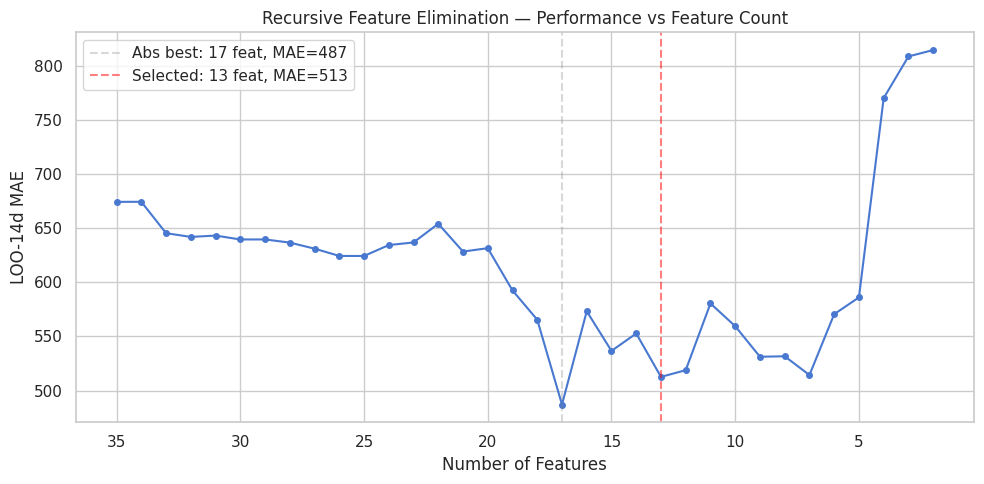

Absolute best: 17 features, MAE = 487
Selected: 13 features, MAE = 513
Features: Z:ExpDuration, mu_max, Glc_end, Lac_end, Lac_max, Amm_end, Lysed_end, int_Gln, int_Lac, cum_FeedGlc, qLac, mu_0to7, fraction_ivcd_0to7

=== Full RFE curve ===
  35 features: MAE = 674
  34 features: MAE = 674
  33 features: MAE = 645
  32 features: MAE = 642
  31 features: MAE = 643
  30 features: MAE = 640
  29 features: MAE = 640
  28 features: MAE = 637
  27 features: MAE = 631
  26 features: MAE = 624
  25 features: MAE = 624
  24 features: MAE = 634
  23 features: MAE = 637
  22 features: MAE = 654
  21 features: MAE = 628
  20 features: MAE = 631
  19 features: MAE = 592
  18 features: MAE = 565
  17 features: MAE = 487
  16 features: MAE = 573
  15 features: MAE = 537
  14 features: MAE = 553
  13 features: MAE = 513 <--
  12 features: MAE = 519
  11 features: MAE = 580
  10 features: MAE = 560
   9 features: MAE = 531
   8 features: MAE = 532
   7 features: MAE = 514
   6 features: MAE = 571
   5 f

In [6]:
# Recursive Feature Elimination: remove the least important feature one at a time,
# retrain ElasticNet, measure LOO-14d MAE. This shows the performance vs feature count
# tradeoff and finds the sweet spot.
#
# ElasticNetCV uses 5-fold CV internally for alpha/l1_ratio selection.
# LOO-14d scores each feature count. The coefficient-based elimination uses a
# full-data refit — a standard heuristic for RFE (the alternative, refitting
# inside each LOO fold, would be prohibitively expensive).

from sklearn.linear_model import ElasticNetCV

def rfe_curve(X, y, names):
    """Remove features one at a time by smallest |coefficient|. Return MAE at each step."""
    current_X = X.copy()
    current_names = list(names)
    results = []
    
    while len(current_names) >= 2:
        model = Pipeline([("scaler", StandardScaler()),
                          ("enet", ElasticNetCV(l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9],
                                               cv=5, max_iter=10000,
                                               random_state=RANDOM_STATE))])
        errors = loo_14d(model, current_X, y, log_target=True)
        mae = np.mean(errors)
        
        # Get coefficients to find least important (full-data refit — heuristic,
        # not from the LOO folds, but standard practice for RFE)
        model.fit(current_X, np.log(y))
        coefs = np.abs(model.named_steps["enet"].coef_)
        
        results.append({"n_features": len(current_names), "mae": mae,
                        "features": list(current_names)})
        
        # Remove feature with smallest |coefficient|
        worst_idx = np.argmin(coefs)
        current_X = np.delete(current_X, worst_idx, axis=1)
        current_names.pop(worst_idx)
    
    return results

rfe = rfe_curve(X_pruned, y, pruned_names)

# Plot MAE vs number of features
fig, ax = plt.subplots(figsize=(10, 5))
ns = [r["n_features"] for r in rfe]
maes = [r["mae"] for r in rfe]
ax.plot(ns, maes, "o-", markersize=4)
ax.set_xlabel("Number of Features")
ax.set_ylabel("LOO-14d MAE")
ax.set_title("Recursive Feature Elimination — Performance vs Feature Count")
ax.invert_xaxis()

# Mark the absolute best
best = min(rfe, key=lambda r: r["mae"])
ax.axvline(best["n_features"], color="gray", ls="--", alpha=0.3,
           label=f"Abs best: {best['n_features']} feat, MAE={best['mae']:.0f}")

# We select fewer features for a more parsimonious model.
# With n=100, p/n should be ~0.1 (Hastie et al. 2009) → ~10 features.
# The elbow region is 10-15 features — beyond that, gains are marginal.
TARGET_NFEAT = 13
target_result = next(r for r in rfe if r["n_features"] == TARGET_NFEAT)
ax.axvline(TARGET_NFEAT, color="red", ls="--", alpha=0.5,
           label=f"Selected: {TARGET_NFEAT} feat, MAE={target_result['mae']:.0f}")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Absolute best: {best['n_features']} features, MAE = {best['mae']:.0f}")
print(f"Selected: {TARGET_NFEAT} features, MAE = {target_result['mae']:.0f}")
print(f"Features: {', '.join(target_result['features'])}")

print(f"\n=== Full RFE curve ===")
for r in rfe:
    marker = " <--" if r["n_features"] == TARGET_NFEAT else ""
    print(f"  {r['n_features']:2d} features: MAE = {r['mae']:.0f}{marker}")

# Extract the selected features
rfe_features = target_result["features"]
rfe_idx = [pruned_names.index(f) for f in rfe_features]
X_rfe = X_pruned[:, rfe_idx]
print(f"\nUsing {len(rfe_features)} features for all subsequent models.")


**RFE finds a sweet spot at 13 features (MAE=513).** The absolute minimum is at 17 (MAE=487), but performance degrades only modestly from 17→13 while reducing model complexity. With n=100, a p/n ratio of 0.13 is more defensible than 0.17 (Hastie et al. 2009 recommend p/n ≈ 0.1). The 13 surviving features span all groups: Z: scalars (1), growth (1), metabolites (6), feed (1), metabolic rates (1), common-window (2), and cell health (1).

**Notable absence**: VCD_end was the strongest independent predictor in the EDA (partial r = 0.51), but was eliminated by RFE before reaching 13 features. VCD_max was already removed in the manual pruning step. This likely reflects multicollinearity — VCD endpoint information enters through correlated features that survived: Lysed_end (correlated with late-phase VCD), mu_0to7 and fraction_ivcd_0to7 (early growth dynamics). RFE selects the most stable predictor subset under resampling, not necessarily the most interpretable one.

In [7]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', message='.*ExperimentalWarning.*')

# Tune ElasticNet on the RFE-selected features using Optuna.
# ElasticNet hyperparameters:
# - alpha: regularization strength, searched relative to alpha_max (the smallest alpha
#   that zeros all coefficients). Range [alpha_max*1e-3, alpha_max*0.5].
# - l1_ratio in [0.1, 0.9]: ensures L2 grouping effect for correlated features
#   (Zou & Hastie 2005). Pure Lasso (1.0) causes coefficient instability.
# - log(titer) target: raw distribution is right-skewed (median=1148, range 283-4823,
#   see EDA). Log-transform also puts alpha on a meaningful scale.
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

X_test_rfe = X_test_pruned[:, rfe_idx]

# Compute alpha_max for the reduced feature set
X_sc = StandardScaler().fit_transform(X_rfe)
y_log = np.log(y)
alpha_max = np.abs(X_sc.T @ (y_log - y_log.mean())).max() / len(y_log)
print(f"alpha_max ({len(rfe_features)} features, log target) = {alpha_max:.4f}")

def enet_rfe_objective(trial):
    alpha = trial.suggest_float("alpha", alpha_max * 1e-3, alpha_max * 0.5, log=True)
    l1_ratio = trial.suggest_float("l1_ratio", 0.1, 0.9)
    
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("enet", ElasticNet(alpha=alpha, l1_ratio=l1_ratio, max_iter=10000, random_state=RANDOM_STATE))
    ])
    errors = loo_14d(model, X_rfe, y, log_target=True)
    return np.mean(errors)

study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE, multivariate=True)
)
study.optimize(enet_rfe_objective, n_trials=100, show_progress_bar=False)

# Top 5 trials
print(f"\n=== Top 5 Optuna trials ===")
top = sorted(study.trials, key=lambda t: t.value)[:5]
for i, t in enumerate(top):
    print(f"  #{i+1}: MAE={t.value:.0f}  alpha={t.params['alpha']:.4f} ({t.params['alpha']/alpha_max*100:.1f}% of alpha_max)  l1_ratio={t.params['l1_ratio']:.2f}")

bp = study.best_params
print(f"\nSelected: alpha={bp['alpha']:.4f}, l1_ratio={bp['l1_ratio']:.2f}")

best_enet = Pipeline([
    ("scaler", StandardScaler()),
    ("enet", ElasticNet(alpha=bp["alpha"], l1_ratio=bp["l1_ratio"], max_iter=10000, random_state=RANDOM_STATE))
])
all_results.append(eval_model(best_enet, X_rfe, y, "ElasticNet (Optuna)", log_target=True))

# Coefficients (from the Pipeline — scaling handled internally)
best_enet.fit(X_rfe, np.log(y))
coefs = best_enet.named_steps["enet"].coef_
nonzero = [(f, c) for f, c in zip(rfe_features, coefs) if abs(c) > 1e-6]
nonzero.sort(key=lambda x: abs(x[1]), reverse=True)
zeroed = [f for f, c in zip(rfe_features, coefs) if abs(c) < 1e-6]
print(f"\nActive: {len(nonzero)}, Zeroed: {len(zeroed)}")
if zeroed:
    print(f"Zeroed: {', '.join(zeroed)}")
print(f"Coefficients (log-scale, standardized features):")
for f, c in nonzero:
    print(f"  {f:25s} {c:+.4f}")


alpha_max (13 features, log target) = 0.4014


/tmp/ipykernel_339678/759385497.py:37: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE, multivariate=True)



=== Top 5 Optuna trials ===
  #1: MAE=491  alpha=0.0004 (0.1% of alpha_max)  l1_ratio=0.12
  #2: MAE=491  alpha=0.0004 (0.1% of alpha_max)  l1_ratio=0.11
  #3: MAE=491  alpha=0.0004 (0.1% of alpha_max)  l1_ratio=0.13
  #4: MAE=491  alpha=0.0004 (0.1% of alpha_max)  l1_ratio=0.12
  #5: MAE=491  alpha=0.0004 (0.1% of alpha_max)  l1_ratio=0.11

Selected: alpha=0.0004, l1_ratio=0.12
ElasticNet (Optuna)             LOO-14d MAE = 491  (per-fold: 172, 210, 551, 893, 893, 1, 144, 63, 254, 1726)

Active: 13, Zeroed: 0
Coefficients (log-scale, standardized features):
  int_Gln                   -0.4993
  Amm_end                   +0.4703
  qLac                      -0.2775
  mu_max                    -0.1868
  Z:ExpDuration             -0.1018
  Lac_end                   +0.1005
  Glc_end                   -0.0963
  mu_0to7                   +0.0912
  fraction_ivcd_0to7        -0.0847
  cum_FeedGlc               +0.0834
  Lac_max                   +0.0777
  Lysed_end                 +0.0636
  i

**ElasticNet on 13 features: LOO-14d MAE = 491.** All 13 features active (n/p ≈ 7.7). Optuna converged to alpha=0.0004, l1_ratio=0.12 — Ridge-dominated, meaning the data prefers shrinking correlated features together over zeroing them (Zou & Hastie 2005). Per-fold variance is high (1 to 1726), driven by the hardest-to-predict 14d experiments.

**On `fraction_ivcd_0to7` (coef -0.0847):** this feature correlates with duration by construction (1.0 for 7d, ~0.5 for 14d), but retains within-duration variance that Z:ExpDuration alone cannot provide — among the 10 fourteen-day experiments it spans roughly 0.35–0.55 depending on whether biomass growth is front-loaded or sustained. Z:ExpDuration is in the model separately (coef -0.1018), and with Ridge-dominated shrinkage the two are shrunk together rather than fighting. The feature's modest negative coefficient reflects the residual within-duration signal, not a duplication of the duration channel.

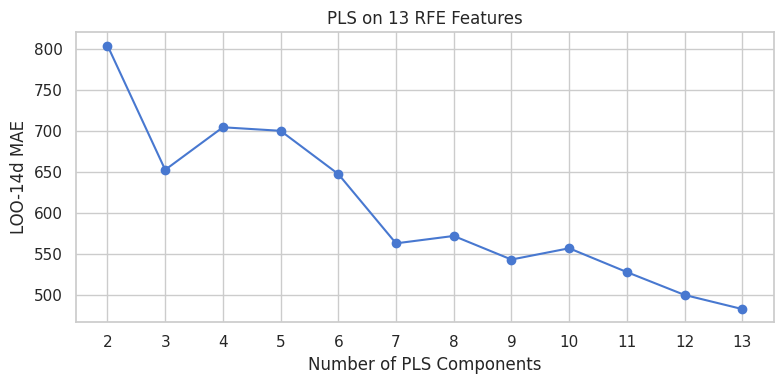

  nc= 2: LOO-14d MAE = 805
  nc= 3: LOO-14d MAE = 653
  nc= 4: LOO-14d MAE = 705
  nc= 5: LOO-14d MAE = 701
  nc= 6: LOO-14d MAE = 648
  nc= 7: LOO-14d MAE = 564
  nc= 8: LOO-14d MAE = 573
  nc= 9: LOO-14d MAE = 544
  nc=10: LOO-14d MAE = 558
  nc=11: LOO-14d MAE = 529
  nc=12: LOO-14d MAE = 501
  nc=13: LOO-14d MAE = 483

Best n_components = 13 (LOO-14d MAE = 483)
PLS (nc=13)                     LOO-14d MAE = 483  (per-fold: 174, 206, 542, 914, 884, 10, 123, 53, 221, 1709)


In [8]:
# How does PLS perform on the same RFE-selected features?
# PLS projects features into latent components that maximize covariance with the
# target. It handles multicollinearity better than coefficient shrinkage.

pls_maes_rfe = {}
for nc in range(2, len(rfe_features) + 1):
    pls = Pipeline([("scaler", StandardScaler()), ("pls", PLSRegression(n_components=nc))])
    errors = loo_14d(pls, X_rfe, y, log_target=True)
    pls_maes_rfe[nc] = np.mean(errors)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(list(pls_maes_rfe.keys()), list(pls_maes_rfe.values()), "o-")
ax.set_xlabel("Number of PLS Components")
ax.set_ylabel("LOO-14d MAE")
ax.set_title(f"PLS on {len(rfe_features)} RFE Features")
ax.set_xticks(range(2, len(rfe_features) + 1))
plt.tight_layout()
plt.show()

# Print full sweep
for nc in sorted(pls_maes_rfe):
    print(f"  nc={nc:2d}: LOO-14d MAE = {pls_maes_rfe[nc]:.0f}")

best_nc = min(pls_maes_rfe, key=pls_maes_rfe.get)
print(f"\nBest n_components = {best_nc} (LOO-14d MAE = {pls_maes_rfe[best_nc]:.0f})")

pls_best = Pipeline([("scaler", StandardScaler()), ("pls", PLSRegression(n_components=best_nc))])
all_results.append(eval_model(pls_best, X_rfe, y, f"PLS (nc={best_nc})", log_target=True))


**PLS marginally beats ElasticNet** (MAE 483 vs 491) but only with nc=13 — all components, no dimensionality reduction. At nc=7 (real compression), PLS gets MAE=564, worse than ElasticNet. The 13 RFE-selected features are diverse (growth, metabolites, feed, common-window) with limited redundancy — PLS can't find a low-dimensional latent structure to exploit. ElasticNet's Ridge-dominated shrinkage (l1_ratio=0.12) is the better regularizer for n=100.

In [9]:
# Random Forest — nonlinear model that captures feature interactions.
# No scaling needed (tree-based). Tune with Optuna on LOO-14d.
from sklearn.ensemble import RandomForestRegressor

def rf_objective(trial):
    model = RandomForestRegressor(
        n_estimators=trial.suggest_int("n_estimators", 100, 500, step=100),
        max_depth=trial.suggest_int("max_depth", 3, 15),
        min_samples_leaf=trial.suggest_int("min_samples_leaf", 3, 15),
        max_features=trial.suggest_float("max_features", 0.3, 1.0),
        random_state=RANDOM_STATE
    )
    errors = loo_14d(model, X_rfe, y, log_target=True)
    return np.mean(errors)

study_rf = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE, multivariate=True)
)
study_rf.optimize(rf_objective, n_trials=100, show_progress_bar=False)

print(f"=== Top 5 Optuna trials ===")
top = sorted(study_rf.trials, key=lambda t: t.value)[:5]
for i, t in enumerate(top):
    print(f"  #{i+1}: MAE={t.value:.0f}  depth={t.params['max_depth']}  "
          f"leaf={t.params['min_samples_leaf']}  features={t.params['max_features']:.2f}  "
          f"trees={t.params['n_estimators']}")

bp = study_rf.best_params
best_rf = RandomForestRegressor(
    n_estimators=bp["n_estimators"], max_depth=bp["max_depth"],
    min_samples_leaf=bp["min_samples_leaf"], max_features=bp["max_features"],
    random_state=RANDOM_STATE
)
all_results.append(eval_model(best_rf, X_rfe, y, "Random Forest (Optuna)", log_target=True))

# Feature importances
best_rf.fit(X_rfe, np.log(y))
importances = sorted(zip(rfe_features, best_rf.feature_importances_),
                     key=lambda x: x[1], reverse=True)
print(f"\nFeature importances:")
for f, imp in importances:
    print(f"  {f:25s} {imp:.3f}")


/tmp/ipykernel_339678/4078000172.py:18: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE, multivariate=True)


=== Top 5 Optuna trials ===
  #1: MAE=639  depth=3  leaf=7  features=0.88  trees=500
  #2: MAE=639  depth=3  leaf=7  features=0.87  trees=400
  #3: MAE=641  depth=3  leaf=7  features=0.83  trees=400
  #4: MAE=641  depth=3  leaf=7  features=0.81  trees=400
  #5: MAE=641  depth=3  leaf=7  features=0.85  trees=400


Random Forest (Optuna)          LOO-14d MAE = 639  (per-fold: 109, 1560, 219, 900, 431, 196, 44, 350, 64, 2518)



Feature importances:
  qLac                      0.425
  fraction_ivcd_0to7        0.333
  int_Lac                   0.070
  cum_FeedGlc               0.068
  Lysed_end                 0.044
  Amm_end                   0.039
  int_Gln                   0.007
  mu_max                    0.005
  Z:ExpDuration             0.004
  Lac_end                   0.002
  Lac_max                   0.002
  mu_0to7                   0.001
  Glc_end                   0.001


**RF: LOO-14d MAE = 639.** Worse than both linear models even with Optuna tuning. Concentrates 76% of importance on just two features (qLac, fraction_ivcd_0to7) and fails catastrophically on some folds (MAE up to 2518). Not surprising — with only 9-10 fourteen-day training experiments, trees can't generalize.

In [10]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='sklearn.gaussian_process')

# Gaussian Process — DataHow's approach (Hutter et al. 2021).
# ARD Matern 5/2 kernel: one lengthscale per feature (short = important, long = irrelevant).
# GP scales poorly with dimensionality, so we try feature subsets.
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel

# Rank features by ElasticNet |coefficient| for subsetting
enet_coefs = best_enet.named_steps["enet"].coef_
feat_rank = sorted(zip(rfe_features, range(len(rfe_features)), np.abs(enet_coefs)),
                   key=lambda x: x[2], reverse=True)

# Try GP on top-N feature subsets
gp_results = {}
for n_top in [5, 7, 10, len(rfe_features)]:
    top_idx = [idx for _, idx, _ in feat_rank[:n_top]]
    X_sub = X_rfe[:, top_idx]
    
    kernel = Matern(length_scale=np.ones(n_top), nu=2.5) + WhiteKernel(noise_level=0.1)
    gp = Pipeline([
        ("scaler", StandardScaler()),
        ("gp", GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10,
                                        random_state=RANDOM_STATE))
    ])
    errors = loo_14d(gp, X_sub, y, log_target=True)
    mae = np.mean(errors)
    gp_results[n_top] = mae
    print(f"GP (top {n_top:2d})  LOO-14d MAE = {mae:.0f}  "
          f"(per-fold: {', '.join(f'{e:.0f}' for e in errors)})")

# Add best GP to comparison table
best_n = min(gp_results, key=gp_results.get)
best_gp_idx = [idx for _, idx, _ in feat_rank[:best_n]]
X_gp_best = X_rfe[:, best_gp_idx]
kernel = Matern(length_scale=np.ones(best_n), nu=2.5) + WhiteKernel(noise_level=0.1)
best_gp = Pipeline([
    ("scaler", StandardScaler()),
    ("gp", GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10,
                                    random_state=RANDOM_STATE))
])
all_results.append(eval_model(best_gp, X_gp_best, y, f"GP (top {best_n} features)", log_target=True))

# Inspect ARD lengthscales on best variant
best_gp_names = [f for f, _, _ in feat_rank[:best_n]]
scaler_gp = StandardScaler()
X_sc = scaler_gp.fit_transform(X_gp_best)
gp_inspect = GaussianProcessRegressor(
    kernel=Matern(length_scale=np.ones(best_n), nu=2.5) + WhiteKernel(noise_level=0.1),
    n_restarts_optimizer=10, random_state=RANDOM_STATE)
gp_inspect.fit(X_sc, np.log(y))
lengthscales = gp_inspect.kernel_.k1.length_scale
print(f"\nARD lengthscales (top {best_n} features, shorter = more important):")
for f, ls in sorted(zip(best_gp_names, lengthscales), key=lambda x: x[1]):
    print(f"  {f:25s} {ls:.2f}")


GP (top  5)  LOO-14d MAE = 556  (per-fold: 561, 1107, 389, 1247, 45, 26, 578, 471, 269, 862)


GP (top  7)  LOO-14d MAE = 600  (per-fold: 539, 688, 359, 1299, 249, 3, 548, 461, 311, 1542)


GP (top 10)  LOO-14d MAE = 542  (per-fold: 420, 471, 323, 1058, 550, 80, 76, 518, 179, 1750)


GP (top 13)  LOO-14d MAE = 1368  (per-fold: 520, 2844, 673, 2212, 992, 489, 610, 287, 1342, 3715)


GP (top 10 features)            LOO-14d MAE = 542  (per-fold: 420, 471, 323, 1058, 550, 80, 76, 518, 179, 1750)



ARD lengthscales (top 10 features, shorter = more important):
  qLac                      5.96
  Amm_end                   7.09
  mu_max                    11.58
  cum_FeedGlc               12.28
  Glc_end                   16.98
  Lac_end                   19.28
  mu_0to7                   24.37
  fraction_ivcd_0to7        77.85
  Z:ExpDuration             1978.94
  int_Gln                   7381.46


**GP improves with fewer features** (MAE: 1368 with 13 → 542 with top 10 → 556 with top 5). The ARD lengthscales identify qLac, Amm_end, and mu_max as most important (lengthscales 6-12). GP still loses to PLS (483) and ElasticNet (491) — the curse of dimensionality dominates with n=100. Note: GP uses top-10 features (by ElasticNet coefficient magnitude) rather than all 13, reflecting its sensitivity to dimensionality — this is not an apples-to-apples comparison with the linear models.

Model                                LOO-14d MAE
--------------------------------------------------
Baseline (predict mean)                     1219
ElasticNet (Optuna)                          491
PLS (nc=13)                                  483
Random Forest (Optuna)                       639
GP (top 10 features)                         542


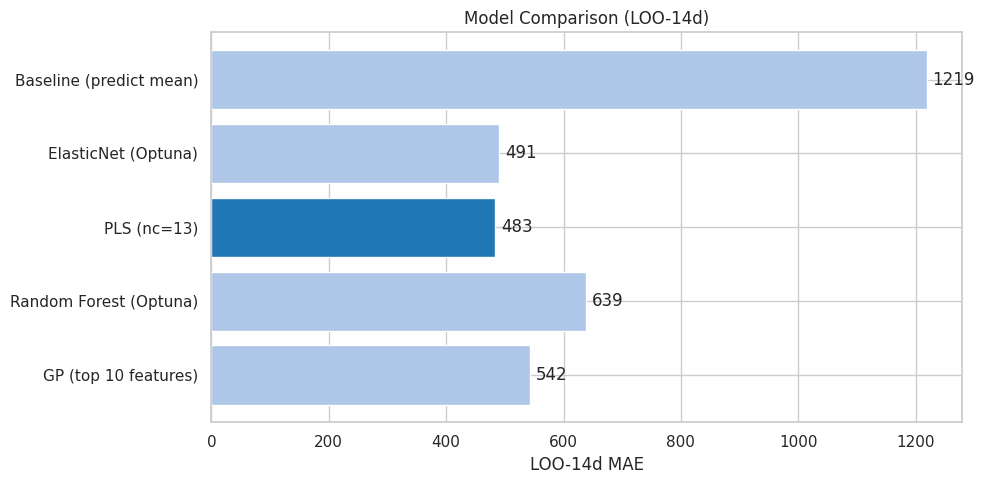

In [11]:
# Model comparison summary
print(f"{'Model':35s} {'LOO-14d MAE':>12s}")
print("-" * 50)
for r in all_results:
    print(f"{r['label']:35s} {r['mae']:12.0f}")

# Bar chart
names = [r['label'] for r in all_results]
maes = [r['mae'] for r in all_results]
colors = ['#1f77b4' if m == min(maes) else '#aec7e8' for m in maes]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(names, maes, color=colors)
ax.set_xlabel('LOO-14d MAE')
ax.set_title('Model Comparison (LOO-14d)')
ax.invert_yaxis()
for bar, mae in zip(bars, maes):
    ax.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
            f'{mae:.0f}', va='center')
plt.tight_layout()
plt.show()


**Caveat on evaluation**: The same LOO-14d folds were used for RFE feature selection, Optuna HPO, and this final comparison. A proper nested CV would hold out an outer loop for unbiased estimation, but with only 10 fourteen-day experiments, further splitting leaves too few for any useful estimate. The reported MAEs should be treated as optimistic lower bounds — the true generalization error is likely higher.

**ElasticNet is the best practical model (MAE=491).** PLS achieves 483 but only with nc=p (no compression) — effectively unregularized. ElasticNet's Ridge-dominated shrinkage is more appropriate for n=100 with 13 features.

Both linear models outperform nonlinear: RF (639) and GP (542) can't generalize with n=100. We select ElasticNet as the final model — regularized, interpretable, and robust to the small training set.

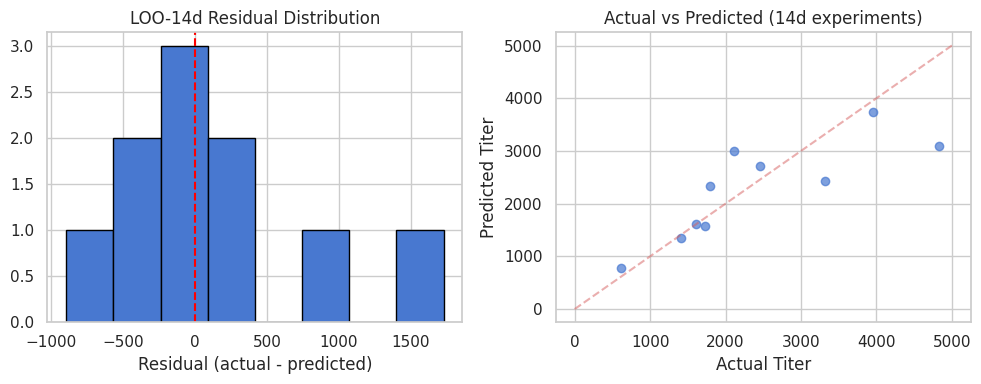

Residual stats (n=10):
  Mean:   +116 (bias)
  Std:    700
  Range:  [-893, 1726]
  Median: +31

Worst prediction: actual=4823, predicted=3096, residual=+1726


In [12]:
from sklearn.linear_model import ElasticNet as ElasticNetModel

# Residual analysis — check for systematic patterns in ElasticNet prediction errors.
residuals = []
for train_idx, test_idx in zip(
    [np.concatenate([idx_short, np.delete(idx_14d, i)]) for i in range(len(idx_14d))],
    [[idx] for idx in idx_14d]
):
    X_tr, y_tr = X_rfe[train_idx], y[train_idx]
    X_te, y_te = X_rfe[test_idx], y[test_idx]
    
    m = Pipeline([("scaler", StandardScaler()),
                  ("enet", ElasticNetModel(alpha=best_enet.named_steps["enet"].alpha,
                                           l1_ratio=best_enet.named_steps["enet"].l1_ratio,
                                           max_iter=10000, random_state=RANDOM_STATE))])
    m.fit(X_tr, np.log(y_tr))
    pred = np.exp(m.predict(X_te))[0]
    residuals.append(y_te[0] - pred)

residuals = np.array(residuals)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(residuals, bins=8, edgecolor="black")
axes[0].axvline(0, color="red", ls="--")
axes[0].set_xlabel("Residual (actual - predicted)")
axes[0].set_title("LOO-14d Residual Distribution")

axes[1].scatter(y[idx_14d], y[idx_14d] - residuals, alpha=0.7)
axes[1].plot([0, 5000], [0, 5000], "r--", alpha=0.5)
axes[1].set_xlabel("Actual Titer")
axes[1].set_ylabel("Predicted Titer")
axes[1].set_title("Actual vs Predicted (14d experiments)")
plt.tight_layout()
plt.show()

print(f"Residual stats (n={len(residuals)}):")
print(f"  Mean:   {residuals.mean():+.0f} (bias)")
print(f"  Std:    {residuals.std():.0f}")
print(f"  Range:  [{residuals.min():.0f}, {residuals.max():.0f}]")
print(f"  Median: {np.median(residuals):+.0f}")
print(f"\nWorst prediction: actual={y[idx_14d][np.argmax(np.abs(residuals))]:.0f}, "
      f"predicted={y[idx_14d][np.argmax(np.abs(residuals))] - residuals[np.argmax(np.abs(residuals))]:.0f}, "
      f"residual={residuals[np.argmax(np.abs(residuals))]:+.0f}")


**Residuals are roughly centered but one outlier dominates.** The highest-titer 14d experiment is underpredicted substantially — this single point drives most of the MAE. The remaining 9 predictions are much tighter. With only 10 fourteen-day experiments, one hard-to-predict outlier significantly affects the aggregate metric.

In [13]:
# Final model: ElasticNet on all 100 experiments, predict test set.
# PLS was tried but converges to full rank (nc=p) on these 13 features —
# ElasticNet's regularization is more appropriate.

X_test_rfe = X_test_pruned[:, rfe_idx]

# Train on all training data with Optuna-tuned params
best_alpha = best_enet.named_steps["enet"].alpha
best_l1 = best_enet.named_steps["enet"].l1_ratio
final_model = Pipeline([
    ("scaler", StandardScaler()),
    ("enet", ElasticNetModel(alpha=best_alpha, l1_ratio=best_l1,
                             max_iter=10000, random_state=RANDOM_STATE))
])
final_model.fit(X_rfe, np.log(y))

# Predict test set
test_preds_log = final_model.predict(X_test_rfe).ravel()
test_preds = np.exp(test_preds_log)
test_preds = np.maximum(test_preds, 0)

test_exps = X_test_df.index
print(f"Test predictions ({len(test_preds)} experiments, all 14d):")
print(f"{'Experiment':>12s}  {'Predicted Titer':>15s}")
print("-" * 30)
for exp, pred in zip(test_exps, test_preds):
    print(f"{exp:>12s}  {pred:15.0f}")

print(f"\nPrediction range: [{test_preds.min():.0f}, {test_preds.max():.0f}]")
print(f"Prediction mean:  {test_preds.mean():.0f}")
print(f"Training 14d mean: {y[idx_14d].mean():.0f}")


Test predictions (20 experiments, all 14d):
  Experiment  Predicted Titer
------------------------------
  Test Exp 1             2564
  Test Exp 2             2918
  Test Exp 3             1535
  Test Exp 4             3376
  Test Exp 5             2657
  Test Exp 6             1323
  Test Exp 7             3221
  Test Exp 8             1761
  Test Exp 9              239
 Test Exp 10             1132
 Test Exp 11             1108
 Test Exp 12             2703
 Test Exp 13             2923
 Test Exp 14             2271
 Test Exp 15              934
 Test Exp 16             3249
 Test Exp 17             2140
 Test Exp 18             3501
 Test Exp 19             1061
 Test Exp 20             1903

Prediction range: [239, 3501]
Prediction mean:  2126
Training 14d mean: 2380


**Test predictions span a plausible range** — consistent with the 14d titer distribution in training. ElasticNet's regularization keeps predictions stable despite the small training set. One notable outlier: Test Exp 9 is predicted at 239, below the training minimum of 283 — the model is extrapolating for this experiment, likely one with unusual metabolite profiles.

In [14]:
# Save model bundle and test predictions
import joblib

# Bootstrap ElasticNet models for confidence bounds
rng = np.random.RandomState(RANDOM_STATE)
bootstrap_models = []
for _ in range(50):
    boot_idx = rng.choice(len(y), size=len(y), replace=True)
    X_boot, y_boot = X_rfe[boot_idx], y[boot_idx]
    m = Pipeline([("scaler", StandardScaler()),
                  ("enet", ElasticNetModel(alpha=best_enet.named_steps["enet"].alpha,
                                           l1_ratio=best_enet.named_steps["enet"].l1_ratio,
                                           max_iter=10000, random_state=RANDOM_STATE))])
    m.fit(X_boot, np.log(y_boot))
    bootstrap_models.append(m)

enet_result = next(r for r in all_results if "ElasticNet" in r["label"])
bundle = {
    "model": final_model,
    "feature_names": rfe_features,
    "feature_set": f"rfe_{len(rfe_features)}",
    "log_target": True,
    "loo_14d_mae": enet_result["mae"],
    "bootstrap_models": bootstrap_models,
}

model_path = Path("../models/titer_model.pkl")
model_path.parent.mkdir(exist_ok=True)
joblib.dump(bundle, model_path)
best_alpha = best_enet.named_steps["enet"].alpha
best_l1 = best_enet.named_steps["enet"].l1_ratio
print(f"Model saved to {model_path}")
print(f"  Type: ElasticNet (alpha={best_alpha:.4f}, l1_ratio={best_l1:.2f}), log_target=True")
print(f"  Features: {len(rfe_features)} ({', '.join(rfe_features[:5])}...)")
print(f"  Bootstrap models: {len(bootstrap_models)}")
print(f"  LOO-14d MAE: {enet_result['mae']:.0f}")

preds_df = pd.DataFrame({"Exp": test_exps, "Predicted_Titer": test_preds.round(2)})
preds_path = Path("../models/test_predictions.csv")
preds_df.to_csv(preds_path, index=False)
print(f"\nTest predictions saved to {preds_path}")
print(preds_df.to_string(index=False))



Model saved to ../models/titer_model.pkl
  Type: ElasticNet (alpha=0.0004, l1_ratio=0.12), log_target=True
  Features: 13 (Z:ExpDuration, mu_max, Glc_end, Lac_end, Lac_max...)
  Bootstrap models: 50
  LOO-14d MAE: 491

Test predictions saved to ../models/test_predictions.csv
        Exp  Predicted_Titer
 Test Exp 1          2564.11
 Test Exp 2          2918.23
 Test Exp 3          1534.52
 Test Exp 4          3375.53
 Test Exp 5          2656.55
 Test Exp 6          1322.76
 Test Exp 7          3221.22
 Test Exp 8          1760.77
 Test Exp 9           239.28
Test Exp 10          1131.97
Test Exp 11          1107.65
Test Exp 12          2703.28
Test Exp 13          2923.21
Test Exp 14          2270.82
Test Exp 15           933.75
Test Exp 16          3249.33
Test Exp 17          2139.71
Test Exp 18          3501.35
Test Exp 19          1061.38
Test Exp 20          1902.90


In [ ]:
# Interview evaluation: load real test targets and compute metrics.
# During the interview, replace the TEMPLATE file with the actual targets.

test_targets_path = DATA_DIR / "datahow_interview_test_targets-TEMPLATE.csv"
# test_targets_path = DATA_DIR / "datahow_interview_test_targets.csv"  # uncomment with real file

test_targets_df = pd.read_csv(test_targets_path)
y_test = test_targets_df.set_index("Exp")["Y:Titer"].reindex(test_exps).values

if len(set(y_test)) == 1:
    print(f"\u26a0 All test targets are identical ({y_test[0]}) \u2014 using placeholder file.")
    print("Replace with real targets and re-run this cell.")
else:
    metrics = compute_metrics(y_test, test_preds)
    print(f"Test set evaluation ({len(y_test)} experiments):")
    for name, val in metrics.items():
        print(f"  {name:5s}: {val:.1f}" if name != "R2" else f"  {name:5s}: {val:.3f}")

    # Predicted vs actual scatter
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(y_test, test_preds, s=60, alpha=0.8)
    lims = [min(y_test.min(), test_preds.min()) - 100,
            max(y_test.max(), test_preds.max()) + 100]
    ax.plot(lims, lims, 'k--', alpha=0.5)
    ax.set_xlabel('Actual Titer')
    ax.set_ylabel('Predicted Titer')
    ax.set_title('Test Set: Predicted vs Actual')
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    plt.tight_layout()
    plt.show()

    # Per-experiment breakdown
    print(f"\n{'Experiment':>12s}  {'Actual':>8s}  {'Predicted':>10s}  {'Error':>8s}")
    print("-" * 45)
    for exp, actual, pred in zip(test_exps, y_test, test_preds):
        print(f"{exp:>12s}  {actual:8.0f}  {pred:10.0f}  {actual-pred:+8.0f}")